## Import Library dan Dataset

In [1]:
!pip install xgboost


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

In [3]:
import pandas as pd
from pathlib import Path

# Membaca dataset hasil penggabungan (cuaca Bandung + harga cabai Jakarta) hasil tahapan Data Cleaning
# Path dibuat fleksibel agar notebook bisa dijalankan dari folder project atau langsung dari folder file.
possible_paths = [
    Path('../dataset/dataset_merge_cleaning.csv'),
    Path('dataset_merge_cleaning.csv'),
    Path('/mnt/data/dataset_merge_cleaning.csv')
]

for path in possible_paths:
    if path.exists():
        df = pd.read_csv(path)
        print(f"Dataset berhasil dibaca dari: {path}")
        break
else:
    raise FileNotFoundError('File dataset_merge_cleaning.csv tidak ditemukan. Pastikan file berada di folder dataset atau satu folder dengan notebook.')

df

Dataset berhasil dibaca dari: ..\dataset\dataset_merge_cleaning.csv


,tanggal,Cabai Merah Besar,Cabai_lag_1,Cabai_lag_7,RR_lag_45,RH_lag_30,RR_rolling_mean_14,bulan
0,2024-06-15,71650.0,71650.000000,65550.0,2.5,70.000000,6.848810,6
1,2024-06-16,71650.0,71650.000000,64450.0,5.0,76.000000,6.346429,6
2,2024-06-17,71650.0,71650.000000,63350.0,3.9,74.000000,5.592857,6
3,2024-06-18,71650.0,71650.000000,65000.0,2.6,72.000000,3.092857,6
4,2024-06-19,77500.0,71650.000000,65000.0,1.3,70.000000,1.426190,6
...,...,...,...,...,...,...,...,...
674,2026-04-20,61450.0,59966.666667,56200.0,1.4,75.333333,12.364286,4
675,2026-04-21,61450.0,61450.000000,56200.0,2.7,71.666667,12.685714,4
676,2026-04-22,63100.0,61450.000000,57000.0,4.0,68.000000,11.900000,4
677,2026-04-23,64600.0,63100.000000,57000.0,5.3,69.000000,11.650000,4


## Split Dataset

In [4]:
# 1. Tentukan Fitur (X) dan Target (y)
# Kita drop kolom 'tanggal' dan target 'Cabai Merah Besar' dari fitur X
X = df.drop(columns=['tanggal', 'Cabai Merah Besar'])
y = df['Cabai Merah Besar']

In [5]:
# 2. Split data secara kronologis (80% Train, 20% Test)
# Karena shuffle=False, data otomatis terpotong berdasarkan urutan waktu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Jumlah data latih (Train): {X_train.shape[0]} baris")
print(f"Jumlah data uji (Test): {X_test.shape[0]} baris")

Jumlah data latih (Train): 543 baris
Jumlah data uji (Test): 136 baris


## Pembuatan Model

In [6]:
# Inisialisasi model dengan hyperparameter yang stabil
models = {
    'Linear Regression (Baseline)': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42),
    'XGBoost Regressor': XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.05, random_state=42)
}

evaluation_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    evaluation_results.append({
        'Model': name,
        'MAE (Rp)': round(mae, 2),
        'MSE (Rp)': round(mse, 2),
        'RMSE (Rp)': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })

df_komparasi = pd.DataFrame(evaluation_results)
df_komparasi

,Model,MAE (Rp),MSE (Rp),RMSE (Rp),R2 Score
0,Linear Regression (Baseline),817.17,1507123.85,1227.65,0.9817
1,Random Forest Regressor,979.52,2102651.82,1450.05,0.9745
2,XGBoost Regressor,1116.41,2547436.47,1596.07,0.9691


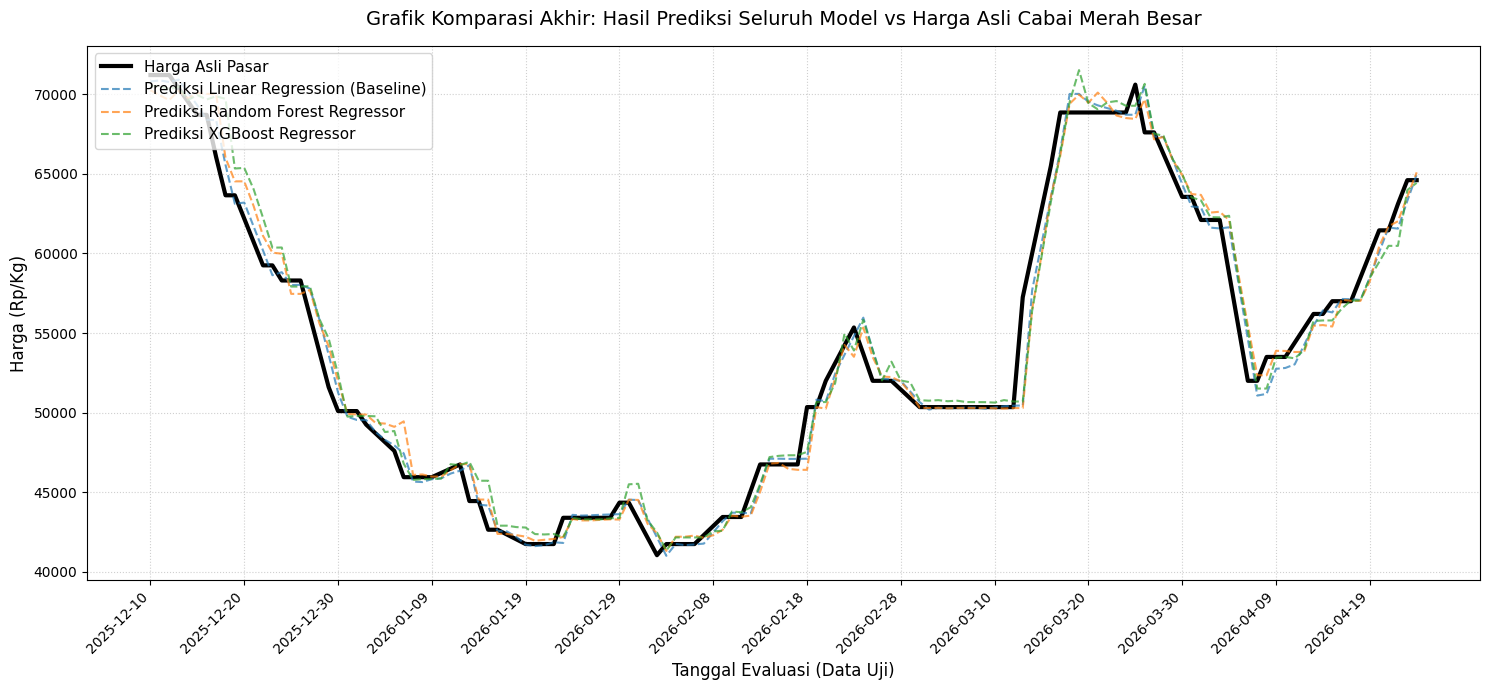

In [ ]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

test_dates = pd.to_datetime(df['tanggal'].iloc[-len(y_test):])

fig, ax = plt.subplots(figsize=(15, 7))

# 1. Plot Harga Asli
ax.plot(test_dates, y_test.values, label='Harga Asli Pasar', color='black', linewidth=3, linestyle='-')

# 2. Plot Tebakan Model Tabular
for name, model in models.items():
    y_pred = model.predict(X_test)
    ax.plot(test_dates, y_pred, label=f'Prediksi {name}', alpha=0.7, linestyle='--')

ax.set_title('Grafik Komparasi Akhir: Hasil Prediksi Seluruh Model vs Harga Asli Cabai Merah Besar', fontsize=14, pad=15)
ax.set_xlabel('Tanggal Evaluasi (Data Uji)', fontsize=12)
ax.set_ylabel('Harga (Rp/Kg)', fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_xticks(test_dates[::10])
fig.autofmt_xdate(rotation=45)

plt.tight_layout()
plt.show()

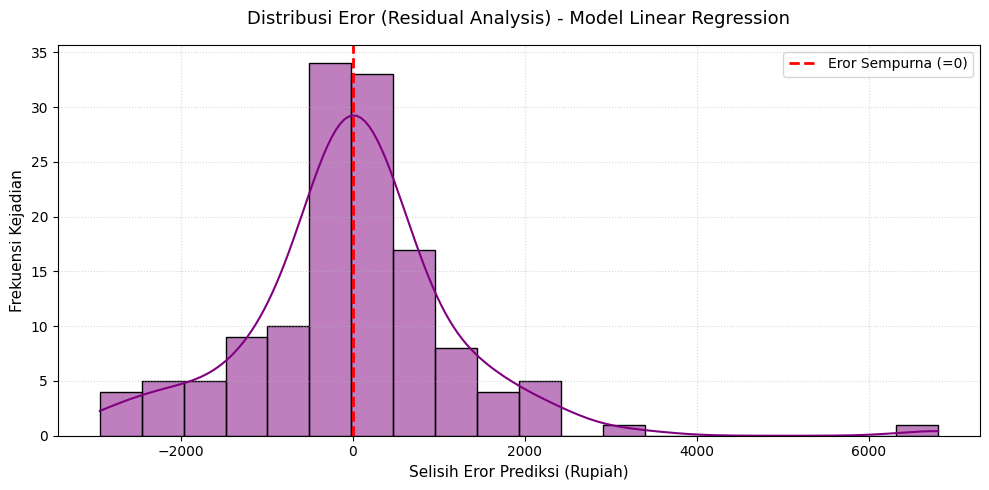

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Ambil model terbaik (Linear Regression) untuk dianalisis sisaannya
best_model = models['Linear Regression (Baseline)']
y_pred_best = best_model.predict(X_test)

# 2. Hitung nilai residual (Error = Aktual - Prediksi)
residuals = y_test - y_pred_best

# 3. Buat visualisasi distribusi residual
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='purple', bins=20, ax=ax)
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Eror Sempurna (=0)')

plt.title('Distribusi Eror (Residual Analysis) - Model Linear Regression', fontsize=13, pad=15)
plt.xlabel('Selisih Eror Prediksi (Rupiah)', fontsize=11)
plt.ylabel('Frekuensi Kejadian', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## Penjelasan Tahap Pemodelan
Tahap pemodelan ini dirancang untuk membandingkan performa tiga algoritma dengan karakteristik arsitektur yang berbeda guna menemukan model yang paling presisi dan stabil dalam memprediksi harga cabai harian:

1. **Linear Regression (Baseline):** Model statistik klasik yang memetakan hubungan linear garis lurus antara seluruh fitur prediktor terhadap target harga. Model ini sangat efisien dan kuat dalam menangkap korelasi kuat jangka pendek seperti hubungan harga hari ini dengan harga kemarin (`Cabai_lag_1`).
2. **Random Forest Regressor:** Model berbasis *Ensemble Learning* yang mengombinasikan ratusan pohon keputusan (*Decision Trees*) secara independen (*Bagging*). Model ini unggul dalam menangkap hubungan non-linear dan interaksi kompleks antar variabel cuaca tanpa risiko *overfitting* yang tinggi.
3. **XGBoost Regressor (Extreme Gradient Boosting):** Model tingkat lanjut berbasis pohon keputusan yang dilatih secara bertahap dan korektif (*Boosting*). Model ini sangat sensitif terhadap pola eror dari iterasi sebelumnya dan terbukti sangat kuat untuk pola data tabular yang dinamis.

**Strategi Validasi Data:**
Pembagian dataset dilakukan secara kronologis menggunakan skema *Time Series Split* dengan proporsi **80% Data Latih (Train Set)** untuk proses pembelajaran model dan **20% Data Uji (Test Set)** untuk menguji performa prediksi ke masa depan. Pengacakan data (*shuffle*) dinonaktifkan sepenuhnya demi menjaga struktur urutan waktu asli data runtun waktu.

## Evaluasi dan Pengujian Model

Tahap evaluasi dilakukan untuk mengukur seberapa baik model yang telah dilatih mampu memprediksi **harga Cabai Merah Besar pada data uji**. Karena data yang digunakan berbentuk runtun waktu (*time series*), pembagian data dilakukan secara kronologis menggunakan **80% data awal sebagai data latih** dan **20% data terakhir sebagai data uji** tanpa pengacakan data (`shuffle=False`).

Evaluasi dilakukan menggunakan beberapa pendekatan:

1. **Evaluasi kuantitatif** menggunakan MAE, RMSE, MAPE, dan $R^2$.
2. **Perbandingan visual** antara harga aktual dan hasil prediksi.
3. **Residual analysis** untuk melihat pola kesalahan model.
4. **Time Series Cross Validation** sebagai validasi tambahan.
5. **Pengujian model pada data baru/skenario prediksi**.

### 1. Evaluasi Kuantitatif Model

Metrik evaluasi yang digunakan adalah:

- **MAE (Mean Absolute Error):** rata-rata selisih absolut antara harga aktual dan harga prediksi. Semakin kecil nilainya, semakin baik model.
- **RMSE (Root Mean Squared Error):** akar dari rata-rata kuadrat error. Metrik ini lebih sensitif terhadap error besar.
- **MAPE (Mean Absolute Percentage Error):** rata-rata error dalam bentuk persentase terhadap harga aktual.
- **$R^2$ Score:** menunjukkan seberapa besar variasi harga aktual yang dapat dijelaskan oleh model.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import pandas as pd

# Evaluasi ulang semua model pada data testing
evaluasi_model = []
prediksi_model = {}

for nama_model, model in models.items():
    y_pred = model.predict(X_test)
    prediksi_model[nama_model] = y_pred

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    r2 = r2_score(y_test, y_pred)

    evaluasi_model.append({
        'Model': nama_model,
        'MAE (Rp)': round(mae, 2),
        'RMSE (Rp)': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'R2 Score': round(r2, 4)
    })

df_evaluasi = pd.DataFrame(evaluasi_model).sort_values(by='MAE (Rp)').reset_index(drop=True)
df_evaluasi

,Model,MAE (Rp),RMSE (Rp),MAPE (%),R2 Score
0,Linear Regression (Baseline),817.17,1227.65,1.49,0.9817
1,Random Forest Regressor,979.52,1450.05,1.77,0.9745
2,XGBoost Regressor,1116.41,1596.07,2.04,0.9691


In [10]:
# Menentukan model terbaik berdasarkan MAE terkecil
nama_model_terbaik = df_evaluasi.loc[0, 'Model']
model_terbaik = models[nama_model_terbaik]
y_pred_terbaik = prediksi_model[nama_model_terbaik]

print(f"Model terbaik berdasarkan MAE terkecil: {nama_model_terbaik}")
print(f"MAE  : Rp {df_evaluasi.loc[0, 'MAE (Rp)']:,.2f}")
print(f"RMSE : Rp {df_evaluasi.loc[0, 'RMSE (Rp)']:,.2f}")
print(f"MAPE : {df_evaluasi.loc[0, 'MAPE (%)']:.2f}%")
print(f"R2   : {df_evaluasi.loc[0, 'R2 Score']:.4f}")

Model terbaik berdasarkan MAE terkecil: Linear Regression (Baseline)
MAE  : Rp 817.17
RMSE : Rp 1,227.65
MAPE : 1.49%
R2   : 0.9817


### 1.1 Baseline Forecast (Naive Forecast)

Sebagai pembanding, digunakan metode **Naive Forecast**, yaitu mengasumsikan bahwa harga cabai hari ini sama dengan harga cabai pada hari sebelumnya (`Cabai_lag_1`). Baseline ini penting karena data harga komoditas memiliki pola time series dan biasanya sangat dipengaruhi oleh harga pada periode sebelumnya.

Berdasarkan output, **Naive Forecast menghasilkan MAE sebesar Rp 791,91, RMSE sebesar Rp 1.342,04, MAPE sebesar 1,44%, dan R² sebesar 0,9781**. Nilai ini menunjukkan bahwa harga cabai hari sebelumnya sudah menjadi prediktor yang sangat kuat.

Jika dibandingkan dengan model machine learning, **Naive Forecast memiliki MAE dan MAPE paling rendah**, sedangkan **Linear Regression memiliki RMSE dan R² yang sedikit lebih baik**. Artinya, model Linear Regression tidak sepenuhnya mengalahkan baseline sederhana dari semua sisi. Hal ini perlu dijelaskan secara jujur karena menunjukkan bahwa pola harga cabai sangat didominasi oleh autokorelasi harga historis.


In [11]:
# Baseline Forecast: prediksi harga hari ini = harga 1 hari sebelumnya
# Karena fitur Cabai_lag_1 sudah tersedia di X_test, baseline dapat langsung dihitung.
y_pred_naive = X_test['Cabai_lag_1']

mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
mape_naive = mean_absolute_percentage_error(y_test, y_pred_naive) * 100
r2_naive = r2_score(y_test, y_pred_naive)

baseline_result = pd.DataFrame({
    'Model': ['Naive Forecast'],
    'MAE (Rp)': [round(mae_naive, 2)],
    'RMSE (Rp)': [round(rmse_naive, 2)],
    'MAPE (%)': [round(mape_naive, 2)],
    'R2 Score': [round(r2_naive, 4)]
})

baseline_result

,Model,MAE (Rp),RMSE (Rp),MAPE (%),R2 Score
0,Naive Forecast,791.91,1342.04,1.44,0.9781


In [12]:
# Perbandingan baseline dengan model machine learning
comparison_with_baseline = pd.concat(
    [baseline_result, df_evaluasi],
    ignore_index=True
).sort_values(by='MAE (Rp)').reset_index(drop=True)

comparison_with_baseline

,Model,MAE (Rp),RMSE (Rp),MAPE (%),R2 Score
0,Naive Forecast,791.91,1342.04,1.44,0.9781
1,Linear Regression (Baseline),817.17,1227.65,1.49,0.9817
2,Random Forest Regressor,979.52,1450.05,1.77,0.9745
3,XGBoost Regressor,1116.41,1596.07,2.04,0.9691


**Interpretasi:**

Naive Forecast digunakan untuk menjawab apakah model machine learning benar-benar memberikan peningkatan performa dibandingkan pendekatan sederhana. Jika nilai MAE model terbaik lebih rendah daripada Naive Forecast, maka model tidak hanya mengikuti harga hari sebelumnya, tetapi mampu memanfaatkan kombinasi fitur lain untuk meningkatkan akurasi prediksi.

**Interpretasi:**

Model dengan nilai **MAE paling kecil** dipilih sebagai model terbaik karena MAE menunjukkan rata-rata kesalahan prediksi dalam satuan rupiah. Jika nilai MAE berada di kisaran ratusan hingga sekitar seribu rupiah, maka error model relatif kecil dibandingkan rentang harga cabai yang dapat mencapai puluhan ribu rupiah. Nilai **MAPE** juga membantu membaca error dalam bentuk persentase, sedangkan nilai **$R^2$** yang mendekati 1 menunjukkan bahwa model mampu menjelaskan sebagian besar variasi harga aktual. Pemilihan model terbaik pada penelitian ini menggunakan MAE sebagai metrik utama karena lebih mudah diinterpretasikan dalam satuan rupiah dan tidak terlalu sensitif terhadap outlier dibanding RMSE.

### 2. Perbandingan Harga Aktual dan Harga Prediksi

Visualisasi berikut digunakan untuk melihat apakah pola prediksi model mampu mengikuti pergerakan harga aktual pada data uji. Model yang baik tidak hanya memiliki nilai error kecil, tetapi juga mampu mengikuti arah kenaikan dan penurunan harga.

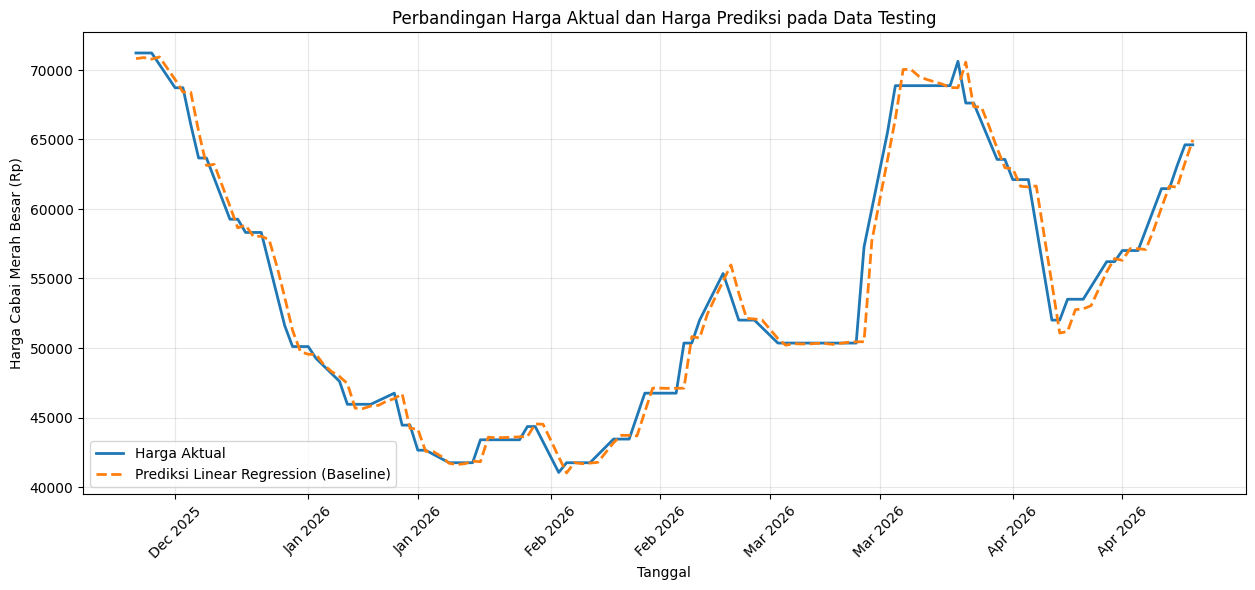

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Mengambil tanggal untuk data testing
test_dates = pd.to_datetime(df['tanggal'].iloc[-len(y_test):])

plt.figure(figsize=(15, 6))
plt.plot(test_dates, y_test.values, label='Harga Aktual', linewidth=2)
plt.plot(test_dates, y_pred_terbaik, label=f'Prediksi {nama_model_terbaik}', linestyle='--', linewidth=2)

plt.title('Perbandingan Harga Aktual dan Harga Prediksi pada Data Testing')
plt.xlabel('Tanggal')
plt.ylabel('Harga Cabai Merah Besar (Rp)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.show()

**Interpretasi:**

Grafik perbandingan harga aktual dan prediksi digunakan untuk mengevaluasi kemampuan model dalam mengikuti pola fluktuasi harga cabai pada data uji. Semakin dekat garis prediksi terhadap garis aktual, maka semakin baik kemampuan model dalam merepresentasikan kondisi sebenarnya. Selisih antara garis aktual dan prediksi menunjukkan besarnya error. Pada model terbaik, jarak kedua garis relatif kecil pada sebagian besar periode data uji, sehingga hasil visual ini mendukung nilai MAE dan RMSE yang diperoleh sebelumnya.

### 3. Tabel Hasil Prediksi Data Testing

Tabel berikut menampilkan perbandingan nilai aktual, nilai prediksi, dan error prediksi pada setiap tanggal data uji. Tabel ini membantu melihat tanggal-tanggal ketika model menghasilkan error paling besar.

In [14]:
df_hasil_prediksi = pd.DataFrame({
    'tanggal': test_dates.values,
    'harga_aktual': y_test.values,
    'harga_prediksi': y_pred_terbaik,
})

df_hasil_prediksi['error'] = df_hasil_prediksi['harga_aktual'] - df_hasil_prediksi['harga_prediksi']
df_hasil_prediksi['absolute_error'] = abs(df_hasil_prediksi['error'])
df_hasil_prediksi['absolute_percentage_error (%)'] = (
    df_hasil_prediksi['absolute_error'] / df_hasil_prediksi['harga_aktual'] * 100
)

# Membulatkan angka agar lebih mudah dibaca
df_hasil_prediksi[['harga_prediksi', 'error', 'absolute_error', 'absolute_percentage_error (%)']] = \
    df_hasil_prediksi[['harga_prediksi', 'error', 'absolute_error', 'absolute_percentage_error (%)']].round(2)

df_hasil_prediksi.head(10)

,tanggal,harga_aktual,harga_prediksi,error,absolute_error,absolute_percentage_error (%)
0,2025-12-10,71200.000000,70794.68,405.32,405.32,0.57
1,2025-12-11,71200.000000,70869.20,330.80,330.80,0.46
2,2025-12-12,71200.000000,70759.74,440.26,440.26,0.62
3,2025-12-13,70366.666667,70915.52,-548.86,548.86,0.78
4,2025-12-14,69533.333333,70103.55,-570.22,570.22,0.82
5,2025-12-15,68700.000000,69289.39,-589.39,589.39,0.86
6,2025-12-16,68700.000000,68389.91,310.09,310.09,0.45
7,2025-12-17,66050.000000,68373.45,-2323.45,2323.45,3.52
8,2025-12-18,63650.000000,65569.10,-1919.10,1919.10,3.02
9,2025-12-19,63650.000000,63116.06,533.94,533.94,0.84


In [15]:
# Menampilkan 10 prediksi dengan error terbesar
df_hasil_prediksi.sort_values(by='absolute_error', ascending=False).head(10)

,tanggal,harga_aktual,harga_prediksi,error,absolute_error,absolute_percentage_error (%)
93,2026-03-13,57250.000000,50447.34,6802.66,6802.66,11.88
70,2026-02-18,50350.000000,47110.72,3239.28,3239.28,6.43
106,2026-03-26,67600.000000,70539.62,-2939.62,2939.62,4.35
115,2026-04-04,58733.333333,61640.94,-2907.60,2907.60,4.95
116,2026-04-05,55366.666667,58155.22,-2788.56,2788.56,5.04
117,2026-04-06,52000.000000,54627.83,-2627.83,2627.83,5.05
97,2026-03-17,68850.000000,66452.92,2397.08,2397.08,3.48
7,2025-12-17,66050.000000,68373.45,-2323.45,2323.45,3.52
119,2026-04-08,53500.000000,51181.44,2318.56,2318.56,4.33
94,2026-03-14,60000.000000,57686.63,2313.37,2313.37,3.86


**Interpretasi:**

Baris dengan nilai **absolute_error** terbesar menunjukkan periode ketika model paling sulit memprediksi harga. Umumnya, error besar dapat terjadi saat harga mengalami lonjakan atau penurunan mendadak yang tidak sepenuhnya dapat dijelaskan oleh fitur cuaca dan harga historis. Hal ini wajar pada komoditas pangan karena harga juga dapat dipengaruhi oleh faktor lain seperti distribusi, permintaan musiman, hari besar, dan kebijakan pasar.

### 4. Residual Analysis

Residual adalah selisih antara harga aktual dan harga prediksi:

$$Residual = y_{aktual} - y_{prediksi}$$

Analisis residual dilakukan untuk melihat apakah kesalahan model bersifat acak atau memiliki pola tertentu. Model yang baik idealnya memiliki residual yang tersebar di sekitar angka nol tanpa pola sistematis.

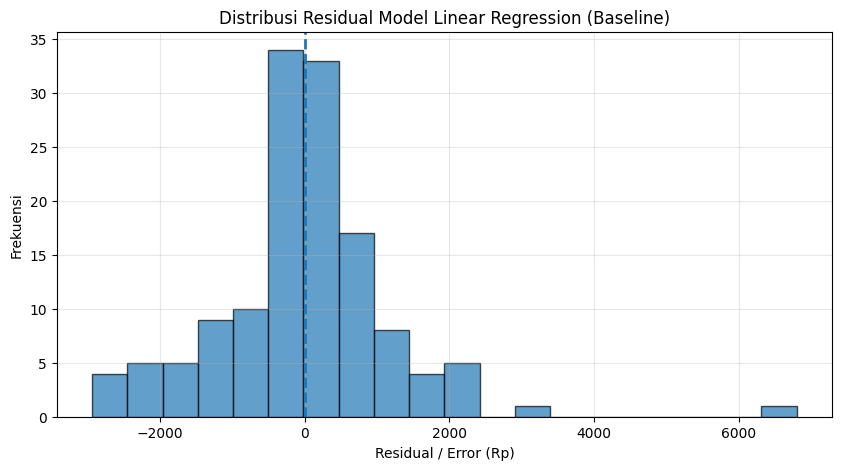

Rata-rata residual: -0.99
Median residual    : 5.38
Std residual       : 1227.65


In [16]:
residual = y_test.values - y_pred_terbaik

plt.figure(figsize=(10, 5))
plt.hist(residual, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(0, linestyle='--', linewidth=2)
plt.title(f'Distribusi Residual Model {nama_model_terbaik}')
plt.xlabel('Residual / Error (Rp)')
plt.ylabel('Frekuensi')
plt.grid(True, alpha=0.3)
plt.show()

print('Rata-rata residual:', round(np.mean(residual), 2))
print('Median residual    :', round(np.median(residual), 2))
print('Std residual       :', round(np.std(residual), 2))

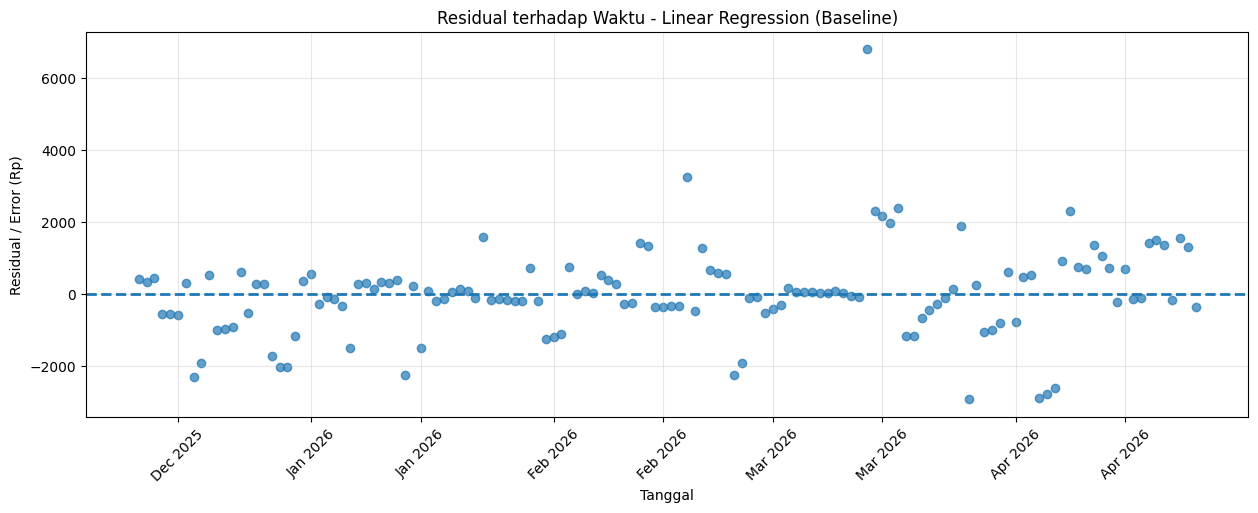

In [17]:
plt.figure(figsize=(15, 5))
plt.scatter(test_dates, residual, alpha=0.7)
plt.axhline(0, linestyle='--', linewidth=2)
plt.title(f'Residual terhadap Waktu - {nama_model_terbaik}')
plt.xlabel('Tanggal')
plt.ylabel('Residual / Error (Rp)')
plt.grid(True, alpha=0.3)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.show()

**Interpretasi:**

Jika residual tersebar secara acak di sekitar garis nol, maka model tidak menunjukkan bias sistematis dalam melakukan prediksi. Residual positif berarti model memprediksi harga lebih rendah daripada harga aktual (*underestimate*), sedangkan residual negatif berarti model memprediksi harga lebih tinggi daripada harga aktual (*overestimate*). Rata-rata residual yang mendekati nol menunjukkan bahwa model tidak cenderung terlalu tinggi atau terlalu rendah secara konsisten. Distribusi residual yang mendekati normal dan berpusat di sekitar nol menunjukkan bahwa kesalahan prediksi tidak memiliki pola tertentu dan model tidak mengalami bias yang signifikan.

### 5.1 Feature Importance dan Interpretasi Faktor Prediktor

Analisis feature importance dilakukan untuk mengetahui fitur mana yang paling berpengaruh dalam prediksi harga cabai. Karena model terbaik adalah Linear Regression, interpretasi utama dilakukan menggunakan **standardized coefficient** agar pengaruh antarfitur lebih adil untuk dibandingkan.

Koefisien standar digunakan karena fitur memiliki satuan berbeda, misalnya harga dalam rupiah, curah hujan dalam mm, kelembapan dalam persen, dan bulan dalam angka kalender.

In [20]:
from sklearn.preprocessing import StandardScaler

# Linear Regression dengan fitur yang distandarisasi untuk interpretasi feature importance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_standardized = LinearRegression()
lr_standardized.fit(X_train_scaled, y_train)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Standardized Coefficient': lr_standardized.coef_
})

coef_df['Abs Coefficient'] = coef_df['Standardized Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs Coefficient', ascending=False).reset_index(drop=True)

coef_df

,Feature,Standardized Coefficient,Abs Coefficient
0,Cabai_lag_1,13199.497930,13199.497930
1,Cabai_lag_7,-909.697484,909.697484
2,RR_lag_45,-69.623319,69.623319
3,RR_rolling_mean_14,-60.533094,60.533094
4,bulan,57.656558,57.656558
5,RH_lag_30,19.724623,19.724623


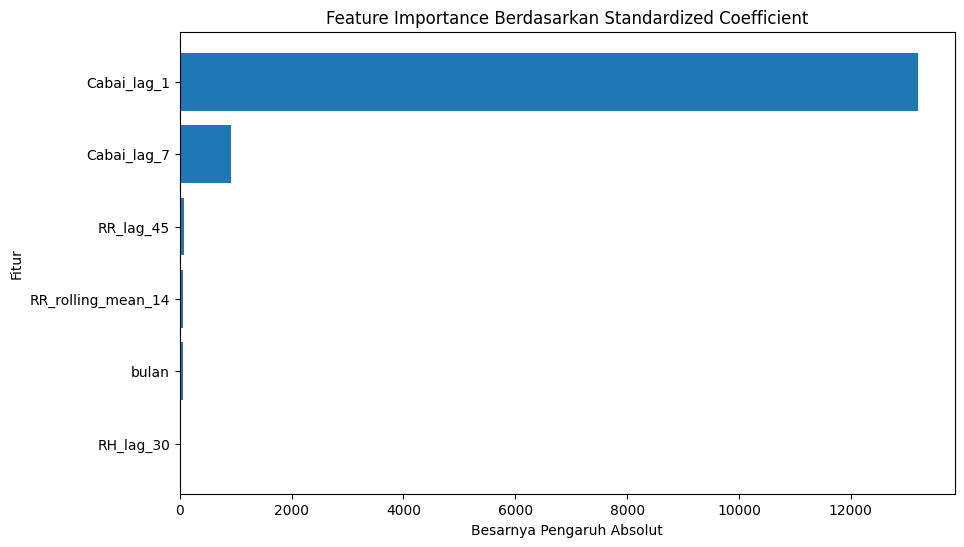

In [21]:
top_features = coef_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Abs Coefficient'])
plt.gca().invert_yaxis()
plt.title('Feature Importance Berdasarkan Standardized Coefficient')
plt.xlabel('Besarnya Pengaruh Absolut')
plt.ylabel('Fitur')
plt.show()

In [22]:
# Feature importance tambahan dari Random Forest untuk membandingkan pola kontribusi fitur
rf_model = models['Random Forest Regressor']

rf_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

rf_importance_df

,Feature,Importance
0,Cabai_lag_1,0.990392
1,RH_lag_30,0.003480
2,RR_rolling_mean_14,0.002203
3,RR_lag_45,0.001937
4,Cabai_lag_7,0.001202
5,bulan,0.000786


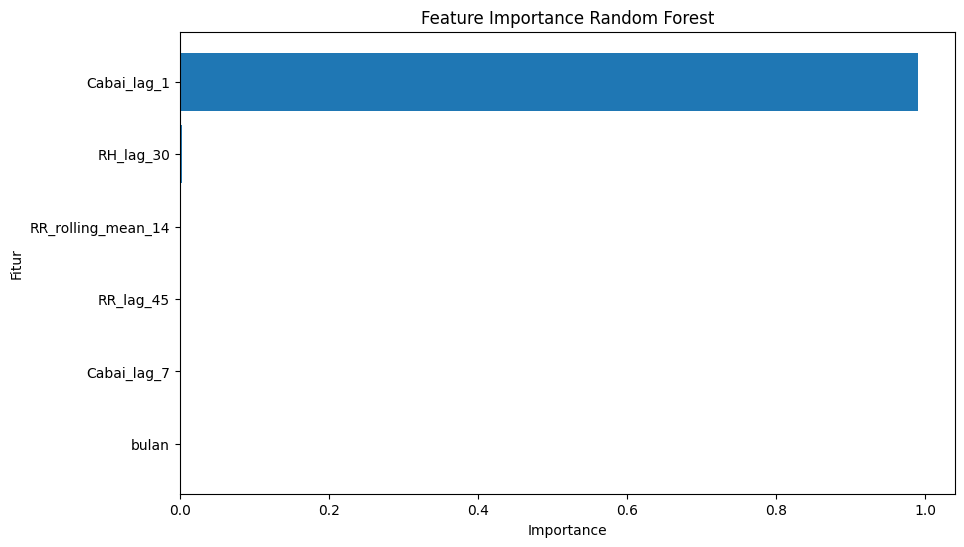

In [23]:
top_rf_features = rf_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_rf_features['Feature'], top_rf_features['Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance Random Forest')
plt.xlabel('Importance')
plt.ylabel('Fitur')
plt.show()

**Interpretasi Feature Importance:**

Berdasarkan standardized coefficient pada Linear Regression, fitur yang paling dominan adalah **`Cabai_lag_1`** dengan nilai koefisien standar sekitar **13.199,50**. Fitur berikutnya adalah **`Cabai_lag_7`** dengan nilai sekitar **909,70**. Jarak kontribusi kedua fitur ini sangat besar dibandingkan fitur lain.

Pada Random Forest, pola yang sama juga terlihat. Fitur **`Cabai_lag_1`** memiliki importance sekitar **0,9904**, atau sekitar 99% dari total kontribusi model. Fitur cuaca seperti **`RH_lag_30`**, **`RR_rolling_mean_14`**, dan **`RR_lag_45`** tetap muncul, tetapi kontribusinya jauh lebih kecil.

Dengan demikian, prediksi harga cabai pada model ini terutama ditentukan oleh **harga historis**, khususnya harga satu hari sebelumnya. Variabel cuaca Bandung tetap masuk ke dalam fitur berpengaruh, tetapi perannya lebih sebagai informasi tambahan, bukan faktor utama dalam model prediksi.


### 5.2 Pembahasan Potensi Data Leakage

Pada data time series, data leakage dapat terjadi apabila informasi dari masa depan ikut digunakan untuk memprediksi data masa lalu atau data saat ini. Hal ini dapat membuat performa model terlihat sangat tinggi, tetapi tidak realistis ketika digunakan pada data baru.

Dalam penelitian ini, potensi data leakage sudah dikendalikan melalui beberapa langkah:

1. Split data dilakukan secara kronologis menggunakan `shuffle=False`, sehingga data testing berada setelah data training.
2. Fitur harga historis menggunakan lag (`Cabai_lag_1` dan `Cabai_lag_7`), sehingga model tidak menggunakan harga pada hari yang sedang diprediksi secara langsung.
3. Fitur cuaca juga dibuat dalam bentuk lag dan rolling mean, sehingga tidak menggunakan informasi cuaca masa depan.

Namun, nilai evaluasi yang sangat tinggi tetap perlu dibahas secara hati-hati. Linear Regression menghasilkan R² sebesar **0,9817**, sedangkan Naive Forecast juga sudah menghasilkan R² sebesar **0,9781**. Selisih yang sangat kecil ini menunjukkan bahwa performa tinggi model terutama berasal dari karakteristik harga cabai yang sangat berkorelasi dengan harga hari sebelumnya.

Jadi, masalah utamanya bukan data leakage langsung, melainkan **dominasi fitur lag harga**. Model memang valid secara time series, tetapi kontribusi variabel cuaca terhadap peningkatan akurasi relatif kecil dibandingkan kontribusi harga historis.


### 5.3 Pengujian Pengaruh Variabel Cuaca

Untuk menguji apakah variabel cuaca benar-benar memberikan informasi terhadap prediksi harga cabai, dilakukan eksperimen tambahan dengan membandingkan dua pendekatan:

- Model dengan seluruh fitur, yaitu harga historis dan cuaca.
- Model dengan fitur cuaca saja, yaitu tanpa `Cabai_lag_1` dan `Cabai_lag_7`.

Eksperimen ini membantu menjelaskan apakah cuaca memiliki kemampuan prediktif secara mandiri, meskipun kemungkinan performanya lebih rendah dibandingkan model yang juga menggunakan harga historis.

In [24]:
# Memilih fitur cuaca saja dengan menghapus fitur lag harga cabai
weather_columns = [
    col for col in X.columns
    if not col.startswith('Cabai_lag')
]

X_weather = X[weather_columns]

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_weather,
    y,
    test_size=0.2,
    shuffle=False
)

weather_model = LinearRegression()
weather_model.fit(X_train_w, y_train_w)

y_pred_weather = weather_model.predict(X_test_w)

mae_weather = mean_absolute_error(y_test_w, y_pred_weather)
rmse_weather = np.sqrt(mean_squared_error(y_test_w, y_pred_weather))
mape_weather = mean_absolute_percentage_error(y_test_w, y_pred_weather) * 100
r2_weather = r2_score(y_test_w, y_pred_weather)

weather_only_result = pd.DataFrame({
    'Model': ['Linear Regression (Hanya Fitur Cuaca)'],
    'MAE (Rp)': [round(mae_weather, 2)],
    'RMSE (Rp)': [round(rmse_weather, 2)],
    'MAPE (%)': [round(mape_weather, 2)],
    'R2 Score': [round(r2_weather, 4)]
})

weather_only_result

,Model,MAE (Rp),RMSE (Rp),MAPE (%),R2 Score
0,Linear Regression (Hanya Fitur Cuaca),11584.85,13443.31,23.51,-1.1951


In [25]:
# Membandingkan model semua fitur, model hanya cuaca, dan naive forecast
best_model_result = df_evaluasi[df_evaluasi['Model'] == nama_model_terbaik].copy()
best_model_result['Model'] = best_model_result['Model'] + ' (Semua Fitur)'

pengaruh_cuaca_comparison = pd.concat(
    [best_model_result, weather_only_result, baseline_result],
    ignore_index=True
).sort_values(by='MAE (Rp)').reset_index(drop=True)

pengaruh_cuaca_comparison

,Model,MAE (Rp),RMSE (Rp),MAPE (%),R2 Score
0,Naive Forecast,791.91,1342.04,1.44,0.9781
1,Linear Regression (Baseline) (Semua Fitur),817.17,1227.65,1.49,0.9817
2,Linear Regression (Hanya Fitur Cuaca),11584.85,13443.31,23.51,-1.1951


**Interpretasi Pengujian Fitur Cuaca:**

Hasil eksperimen menunjukkan bahwa model yang hanya menggunakan fitur cuaca menghasilkan **MAE sebesar Rp 11.584,85, RMSE sebesar Rp 13.443,31, MAPE sebesar 23,51%, dan R² sebesar -1,1951**.

Nilai R² yang negatif menunjukkan bahwa model berbasis fitur cuaca saja belum mampu memprediksi harga cabai dengan baik. Dengan kata lain, variabel cuaca Bandung **tidak cukup kuat apabila digunakan sendirian** untuk menjelaskan perubahan harga cabai merah besar di Jakarta.

Ketika dibandingkan dengan Naive Forecast dan model semua fitur, terlihat bahwa harga historis jauh lebih dominan. Variabel cuaca tetap dapat dianggap memiliki hubungan pendukung karena beberapa fitur cuaca muncul pada feature importance, seperti `RH_lag_30`, `RR_rolling_mean_14`, dan `RR_lag_45`. Namun, berdasarkan hasil eksperimen ini, pengaruh cuaca lebih tepat disimpulkan sebagai **faktor tambahan**, bukan faktor utama prediksi.


### 6. Pengujian Model pada Data Baru

Setelah model terbaik diperoleh, tahap berikutnya adalah menguji apakah model dapat digunakan untuk memprediksi harga pada satu baris data baru. Pada contoh berikut, data baru dibuat berdasarkan struktur fitur yang sama dengan data training.

In [26]:
# Contoh skenario data baru
# Nilai pada data_baru dapat diganti sesuai kondisi aktual yang ingin diuji.

data_baru = pd.DataFrame({
    'Cabai_lag_1': [70000],          # harga cabai 1 hari sebelumnya
    'Cabai_lag_7': [68000],          # harga cabai 7 hari sebelumnya
    'RR_lag_45': [10],               # curah hujan 45 hari sebelumnya
    'RH_lag_30': [82],               # kelembapan 30 hari sebelumnya
    'RR_rolling_mean_14': [7],        # rata-rata curah hujan 14 hari terakhir
    'bulan': [6]                     # bulan prediksi
})

# Menyesuaikan urutan kolom dengan X_train agar aman
data_baru = data_baru[X_train.columns]

prediksi_harga_baru = model_terbaik.predict(data_baru)[0]
print(f"Prediksi harga Cabai Merah Besar untuk data baru adalah: Rp {prediksi_harga_baru:,.2f}")

Prediksi harga Cabai Merah Besar untuk data baru adalah: Rp 69,890.85


**Interpretasi:**

Pengujian pada data baru dilakukan untuk mensimulasikan penggunaan model pada kondisi nyata. Dengan memasukkan nilai fitur yang belum pernah digunakan pada proses evaluasi, model menghasilkan estimasi harga cabai yang dapat digunakan sebagai prediksi untuk periode berikutnya.

### 7. Kesimpulan Evaluasi

Berdasarkan hasil evaluasi pada data testing, **Linear Regression** menghasilkan performa yang sangat baik dengan MAE sebesar **Rp 817,17**, RMSE sebesar **Rp 1.227,65**, MAPE sebesar **1,49%**, dan R² sebesar **0,9817**. Model ini memiliki RMSE dan R² terbaik dibandingkan Random Forest dan XGBoost.

Namun, perbandingan dengan **Naive Forecast** menunjukkan temuan penting. Naive Forecast menghasilkan MAE sebesar **Rp 791,91** dan MAPE sebesar **1,44%**, sedikit lebih baik dibandingkan Linear Regression dari sisi rata-rata error. Artinya, harga cabai hari sebelumnya sudah menjadi prediktor yang sangat kuat, sehingga model machine learning belum secara konsisten mengalahkan baseline sederhana pada seluruh metrik evaluasi.

Analisis feature importance memperkuat temuan tersebut. Fitur **`Cabai_lag_1`** menjadi faktor paling dominan, baik pada Linear Regression maupun Random Forest. Pada Random Forest, kontribusi `Cabai_lag_1` mencapai sekitar **0,9904**, jauh lebih besar dibandingkan fitur lain. Hal ini menunjukkan bahwa prediksi harga cabai dalam model sangat dipengaruhi oleh harga historis.

Variabel cuaca Bandung seperti **kelembapan (`RH_lag_30`)**, **rata-rata curah hujan (`RR_rolling_mean_14`)**, dan **curah hujan lag (`RR_lag_45`)** tetap muncul dalam feature importance, tetapi kontribusinya relatif kecil. Selain itu, model yang hanya menggunakan fitur cuaca menghasilkan performa rendah dengan MAE sebesar **Rp 11.584,85**, MAPE sebesar **23,51%**, dan R² sebesar **-1,1951**. Ini menunjukkan bahwa fitur cuaca saja belum cukup kuat untuk memprediksi harga cabai secara mandiri.

Dengan demikian, dapat disimpulkan bahwa **harga historis merupakan faktor utama dalam prediksi harga cabai merah besar**, sedangkan **cuaca Bandung berperan sebagai faktor pendukung**. Pengaruh cuaca terhadap harga kemungkinan tidak langsung muncul pada hari yang sama, tetapi melalui proses produksi, panen, kualitas hasil panen, ketersediaan pasokan, dan distribusi dari daerah pemasok menuju pasar Jakarta.

Secara keseluruhan, model sudah layak digunakan untuk prediksi jangka pendek karena memiliki error yang rendah. Namun, untuk klaim pengaruh cuaca, kesimpulan yang paling tepat adalah bahwa cuaca memiliki indikasi hubungan terhadap harga, tetapi kontribusinya lebih kecil dibandingkan harga historis.


In [27]:
import joblib

# Simpan model terbaik agar dapat digunakan kembali tanpa training ulang
joblib.dump(model_terbaik, 'model_cabai_lr.pkl')
print('Model terbaik berhasil disimpan sebagai model_cabai_lr.pkl')

Model terbaik berhasil disimpan sebagai model_cabai_lr.pkl
